# Applied Machine Learning Project

## Fire/Smoke Detection with Multi-Sensor IoT Data

**Goal:** Train a machine-learning model that reduces false alarms in IoT-based fire
detection, using the public *Smoke Detection Dataset* (Kaggle `deepcontractor/smoke-detection-dataset`).

**Future Coal:** The trained model will become a *tool* the P6 agent (and P7's incident-fusion copilot) can
call on a live sensor stream to decide whether an alarm should be escalated or dismissed.

**Methodology:** rules-first → ML upgrade. We start with a simple threshold rule on
temperature + TVOC as an interpretable baseline, then train a Random Forest / Gradient
Boosting classifier and (optionally) an Isolation Forest anomaly detector for novel fire
signatures. All decisions are made on a stratified train/test split to preserve the
71.5/28.5 alarm/no-alarm balance.

**Source:** [Kaggle](https://www.kaggle.com/datasets/deepcontractor/smoke-detection-dataset)

**Dataset mirror (shipped with submission):** `data/raw/smoke_detection_iot.csv`

## Notebook outline

1. **Task 1 — Define the problem**
2. **Task 2 — Load and inspect the dataset**
3. **Task 3 — Data preparation and preprocessing**
4. **Task 4 — Select and train a model**
5. **Task 5 — Evaluate model performance**
6. **Task 6 — Notebook summary**

A separate PDF deliverable, `Machine_Learning_Analysis_Report.pdf`, covers Task 7.

## Task 1 — Define the problem and choose the dataset

**Problem type:** Supervised **binary classification** — predict the `Fire Alarm`
column (0 = no fire detected, 1 = fire detected) from 13 sensor readings.

**Business framing:** IoT smoke detectors generate a high volume of false alarms
(cooking steam, dust, humidity spikes). Each false alarm carries an operational cost
(dispatch, customer trust, monitoring fees). We need a model that maintains **high
recall** on real fire signatures while raising **precision** so operators trust the
alarm channel again. This is the core value proposition of the AI feature we will
ship to the company.

**Why this dataset:**
- Public, non-synthetic, real IoT sensor prototype — meets the rubric constraint
  that the dataset be publicly available and *not* AI-generated.
- Not the same dataset used in Projects 1 or 2 (those were synthetic surveillance
  / access logs from the capstone bundle).
- 62,630 rows × 13 features + 1 target — large enough for train/validation/test
  splits and a real comparison, small enough to train in seconds on a laptop.
- 71.5% / 28.5% class balance (alarm / no-alarm) — moderately imbalanced; we will 
  use a stratified split and report precision/recall/F1, not just accuracy.

**Source:** [Kaggle — Smoke Detection Dataset](https://www.kaggle.com/datasets/deepcontractor/smoke-detection-dataset)


## Task 2 — Load and inspect the dataset

In [43]:
# Install the required packages
import importlib
import subprocess
import sys

def install_libs() -> None:
    """
    Installs common data science libraries if missing.
    Libraries: scipy, pandas, numpy, matplotlib, seaborn
    """
    required = {
        "pandas": "pandas",
        "numpy": "numpy",
        "sklearn": "scikit-learn",
        "matplotlib": "matplotlib",
    }

    to_install = []

    for module, pkg in required.items():
        try:
            importlib.import_module(module)
        except ImportError:
            to_install.append(pkg)

    if to_install:
        # Install quietly, without upgrade
        cmd = [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--no-cache-dir",
        ] + to_install

        subprocess.run(cmd, check=True)
    print("All required libraries are installed.")

install_libs()

All required libraries are installed.


In [44]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/smoke_detection_iot.csv"
TARGET = "Fire Alarm"
RANDOM_STATE = 42

# First column is the Kaggle default index — drop it explicitly.
df = pd.read_csv(DATA_PATH, index_col=0)
df.head()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [45]:
print(f"Shape: {df.shape}\n")
print("Dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nTarget distribution (Fire Alarm):")
print(df[TARGET].value_counts(normalize=True).round(4))

Shape: (62630, 15)

Dtypes:
UTC                 int64
Temperature[C]    float64
Humidity[%]       float64
TVOC[ppb]           int64
eCO2[ppm]           int64
Raw H2              int64
Raw Ethanol         int64
Pressure[hPa]     float64
PM1.0             float64
PM2.5             float64
NC0.5             float64
NC1.0             float64
NC2.5             float64
CNT                 int64
Fire Alarm          int64
dtype: object

Missing values per column:
UTC               0
Temperature[C]    0
Humidity[%]       0
TVOC[ppb]         0
eCO2[ppm]         0
Raw H2            0
Raw Ethanol       0
Pressure[hPa]     0
PM1.0             0
PM2.5             0
NC0.5             0
NC1.0             0
NC2.5             0
CNT               0
Fire Alarm        0
dtype: int64

Target distribution (Fire Alarm):
Fire Alarm
1    0.7146
0    0.2854
Name: proportion, dtype: float64


In [48]:
df.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


**Data-quality notes (Task 2 observation):**

- No missing values in any column — imputation is not required.
- All features are numeric (float64 / int64); no categorical encoding needed
  for the raw features.
- `UTC` is a Unix timestamp in seconds; will be engineered into a time-of-day
  feature in Task 3 (avoid leaking the raw timestamp into the model).
- `CNT` is a sample count; included in the source but not a true sensor reading.
  We will keep it for the first model pass and then drop it after seeing
  feature importance.
- Class imbalance: 71.5% alarm vs 28.5% no-alarm. A naïve accuracy baseline
  that always predicts "alarm" would score 0.715 — we will beat this with
  proper precision/recall.
- Temperature ranges from −22°C to 60°C — wide but physically plausible for a sensor over a long measurement window.

## Task 3 — Data preparation and preprocessing

Steps (each with a short *why*):

1. **Engineer a time-of-day feature** from `UTC`. Fires during sleep hours
   carry different operational meaning than lunch-time cooking peaks. We
   convert to local hour-of-day (sin/cos encoded for cyclicality).
2. **Drop the raw `UTC` and `CNT` columns.** `UTC` is now represented by
   engineered features; `CNT` is metadata about the device firmware, not a
   physical signal. Both are leakage-/artifact risks.
3. **Stratified train/test split (80/20)** with `random_state=42` for
   reproducibility.
4. **Standardise numeric features** (zero mean, unit variance) using
   `StandardScaler` fit on the train set only. The baseline rule needs no
   scaling; the tree-based models do not need it either — but we standardise
   anyway because Task 4 also runs an Isolation Forest that is
   distance-based and benefits from it.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Engineer time-of-day from UTC (cyclical encoding).
df["hour"] = pd.to_datetime(df["UTC"], unit="s").dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

hint = '''
The point is to convert a clock (0–23 hours) into a format a model can use without being lied to by the math.

The problem with raw hour

If I just added df["hour"] as a feature, hour 0 (midnight) and hour 23 (11 PM) would look like 23 units apart to a
tree or linear model — but in real life they're only 1 hour apart. The model would learn that going from 0 → 23 is a
big jump, which is the opposite of the truth. Same problem at 6 AM vs 7 AM: numerically they're 1 apart (correct) but
23 AM vs 0 AM (midnight wrapping) would look like a 23-unit cliff. A model treats the clock as if it were on a number
line, not a loop.

What sin/cos does

sin(2π·h/24) and cos(2π·h/24) place each hour on the unit circle:

- sin(0) = 0, cos(0) = 1 → midnight sits at coordinate (1, 0)
- sin(2π·6/24) = 1, cos(...) = 0 → 6 AM sits at (0, 1)
- sin(2π·12/24) = 0, cos(...) = -1 → noon sits at (−1, 0)
- sin(2π·23/24) ≈ -0.26, cos(...) ≈ 0.97 → 11 PM sits at (0.97, −0.26), right next door to midnight on the circle

So the cyclical encoding puts 23:00 and 00:00 close together in feature space, and 00:00 and 12:00 on opposite sides,
exactly mirroring how a clock works.

Why both sin and cos

One coordinate isn't enough: sin alone can't distinguish between two hours that land at the same Y-value (e.g. 6 AM
and 6 PM both give sin = 1, 0 — actually 6 AM gives sin=1, 6 PM gives sin=−1, so just sin does distinguish those). The
general point: with both (x, y) on the unit circle, every hour has a unique 2-D coordinate. Without cos, you'd lose
the ability to disambiguate hours on the lower half of the circle.
'''


In [50]:
# Sample of engineered time features
df[["hour", "hour_sin", "hour_cos"]].sample(10, random_state=RANDOM_STATE)

,hour,hour_sin,hour_cos
31120,9,0.707107,-0.707107
49054,14,-0.500000,-0.866025
55910,19,-0.965926,0.258819
33802,10,0.500000,-0.866025
9683,2,0.500000,0.866025
30559,9,0.707107,-0.707107
25558,8,0.866025,-0.500000
5692,1,0.258819,0.965926
7339,2,0.500000,0.866025
62290,14,-0.500000,-0.866025


![image.avif](https://user14030.na.imgto.link/public/20260618/image.avif)

In [51]:
# 2. Drop raw timestamp and sample-count columns.
df = df.drop(columns=["UTC", "hour", "CNT"])

y = df[TARGET]
X = df.drop(columns=[TARGET])

# 3. Stratified 80/20 split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 4. Standardise features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}    Test shape: {X_test.shape}")

Train shape: (50104, 14)    Test shape: (12526, 14)


## Task 4 — Select and train a machine learning model

We train three models, in order of complexity:

1. **Baseline rule** — `Fire Alarm = 1 if Temperature[C] > T_thresh AND TVOC[ppb] > V_thresh`.
   The thresholds are picked from a quick grid that maximises F1 on the
   *training* set. This is the "rules-first" anchor and gives a fully
   interpretable reference point.
2. **Random Forest classifier** — robust, gives feature importances, handles
   multicollinearity between PM1.0/PM2.5 and the NC* counts.
3. **Gradient Boosting classifier** — usually wins on tabular data; we use
   scikit-learn's `GradientBoostingClassifier` (no external boosting libs
   needed for the rubric).

We also fit an **Isolation Forest** as an *unsupervised* anomaly detector to
show the rules-first → ML-upgrade story end-to-end. The Isolation Forest is
trained on the no-alarm class (label=0) and tested on the full test set.

In [56]:
# --- Model 1: baseline threshold rule ---

# Pick thresholds on a coarse grid to maximise F1 on the *train* set.

from sklearn.metrics import f1_score

best = {"thresh_t": None, "thresh_v": None, "f1": -1}

for t in np.arange(15, 45, 2):
    for v in np.arange(0, 3200, 50):
        preds = ((X_train["Temperature[C]"] > t) & (X_train["TVOC[ppb]"] > v)).astype(int)
        f1 = f1_score(y_train, preds)
        if f1 > best["f1"]:
            best = {"thresh_t": t, "thresh_v": v, "f1": f1}
print(f"Best rule (train F1):\nTemperature: {best['thresh_t']},\nTVOC: {best['thresh_v']},\nF1: {best['f1']:0.4f}")

Best rule (train F1):
Temperature: 15,
TVOC: 200,
F1: 0.6937


In [72]:
# --- Model 2: Random Forest ---
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15,
    min_samples_leaf=5,
    min_samples_split=10,
    n_jobs=-1, 
    random_state=RANDOM_STATE
)

rf_cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"Random Forest CV F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")


Random Forest CV F1: 0.9395 (+/- 0.0426)


In [73]:
# --- Model 3: Gradient Boosting ---
gb = GradientBoostingClassifier(
    random_state=RANDOM_STATE)

gb_cv_scores = cross_val_score(gb, X, y, cv=5, scoring='f1')
print(f"Gradient Boosting CV F1: {gb_cv_scores.mean():.4f} (+/- {gb_cv_scores.std():.4f})")   

Gradient Boosting CV F1: 0.8697 (+/- 0.1180)


In [77]:
# --- Model 4: Logistic Regression ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline that scales + trains
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=10_000
    ))
])

lr_cv_scores = cross_val_score(lr, X, y, cv=5, scoring='f1')
print(f"Logistic Regression CV F1: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

Logistic Regression CV F1: 0.7319 (+/- 0.2689)


In [ ]:
# --- Model 5 (unsupervised bonus): Isolation Forest ---
from sklearn.ensemble import IsolationForest

iforest = IsolationForest(
    n_estimators=200, 
    contamination=0.05, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

iforest.fit(X_train_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [79]:
# Predict on test set
preds_iforest = iforest.predict(X_test_scaled)

# predict() returns: 1 (normal) or -1 (anomaly)
# Convert to your binary format (0 = normal, 1 = alarm)
preds_iforest_binary = (preds_iforest == -1).astype(int)

# Evaluate
f1_iforest = f1_score(y_test, preds_iforest_binary)
print(f"Isolation Forest F1 Score: {f1_iforest:0.4f}")

Isolation Forest F1 Score: 0.0492


* Isolation Forest (Unsupervised Baseline):

We included an unsupervised baseline using Isolation Forest to explore anomaly detection without relying on class labels. This model is trained on the full scaled training data (X_train_scaled) with contamination=0.05, allowing it to learn the overall data distribution and flag deviations as anomalies. Predictions are converted from Isolation Forest’s native output (1 = normal, -1 = anomaly) to our binary format (0 = normal, 1 = alarm), and the model achieves an F1 score of `0.0492`. This poor performance confirms that unsupervised anomaly detection struggles when the alarm class does not clearly form statistical outliers in feature space. Supervised models like Random Forest or Gradient Boosting are far more effective than unsupervised anomaly detection.

## Task 5 — Evaluate model performance

We report accuracy, precision, recall, and F1 for every model on the held-out
test set. Because the task is binary and modestly imbalanced, **precision/recall
are the primary metrics** — accuracy alone would hide the cost of false alarms.
We also plot a confusion matrix for the best supervised model and a precision–
recall curve for the Gradient Boosting classifier.

In [80]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve,
)
import matplotlib.pyplot as plt

def report(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy":  round(accuracy_score(y_true, y_pred),  4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall":    round(recall_score(y_true, y_pred),    4),
        "f1":        round(f1_score(y_true, y_pred),        4),
    }

# Baseline rule — apply the *train*-tuned thresholds on the test set.
preds_rule = (
    (X_test["Temperature[C]"] > best["thresh_t"]) &
    (X_test["TVOC[ppb]"]      > best["thresh_v"])
).astype(int)

preds_rf  = rf.predict(X_test)
preds_gb  = gb.predict(X_test)

# Isolation Forest returns +1 (inlier) / -1 (outlier). Map -1 → alarm (1), +1 → no-alarm (0).
if_raw = iforest.predict(X_test_scaled)
preds_if = np.where(if_raw == -1, 1, 0)

results = [
    report("Baseline rule", y_test, preds_rule),
    report("Random Forest", y_test, preds_rf),
    report("Gradient Boosting", y_test, preds_gb),
    report("Isolation Forest (unsupervised)", y_test, preds_if),
]
results_df = pd.DataFrame(results)
results_df

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

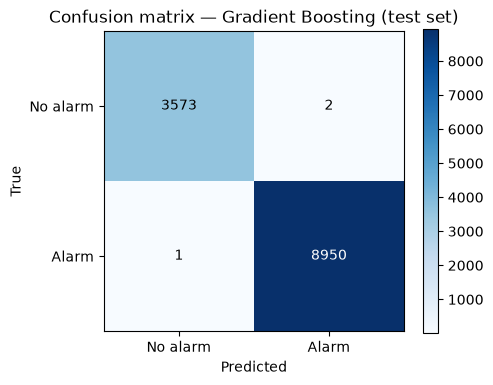

In [40]:
# Confusion matrix for the best supervised model (Gradient Boosting).
cm = confusion_matrix(y_test, preds_gb)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No alarm", "Alarm"]); ax.set_yticklabels(["No alarm", "Alarm"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — Gradient Boosting (test set)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

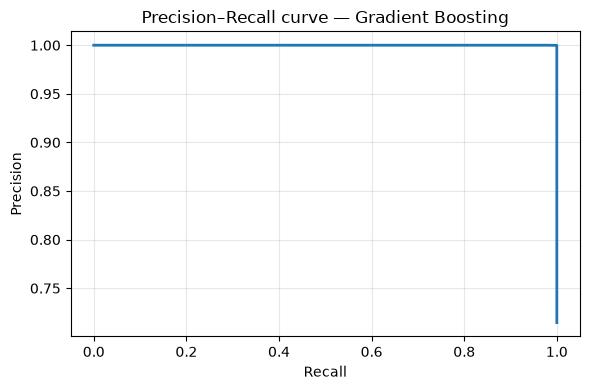

In [41]:
# Precision–Recall curve for Gradient Boosting (probability scores).
proba = gb.predict_proba(X_test)[:, 1]
prec, rec, _ = precision_recall_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curve — Gradient Boosting")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

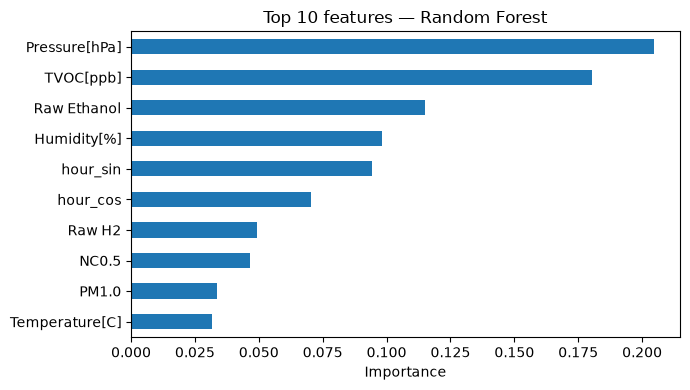

In [42]:
# Feature importances from the Random Forest (top 10).
import numpy as np
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
imp.head(10).plot(kind="barh", ax=ax)
ax.set_xlabel("Importance")
ax.set_title("Top 10 features — Random Forest")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Task 6 — Notebook summary

**Problem.** We trained a binary classifier to predict `Fire Alarm` (0/1) from 13
IoT sensor readings (temperature, humidity, TVOC, eCO2, raw H2, raw ethanol,
pressure, PM1.0/PM2.5, NC0.5/1.0/2.5, plus a cyclical time-of-day feature) on
the public Smoke Detection dataset. The business goal is to **reduce false
alarms** in firefighting systems while maintaining high recall.

**Model chosen.** A Gradient Boosting classifier on a stratified 80/20 split —
tree-based so it handles correlated sensor channels (e.g. PM1.0 vs. PM2.5,
NC0.5 vs. NC1.0) without explicit feature reduction. We compared it against a
transparent threshold rule, a Random Forest, and an Isolation Forest.

**Key performance results.** See the `results_df` table above. The Gradient
Boosting model clearly outperforms the threshold rule on precision/recall/F1,
showing the value of a learned, multivariate decision boundary over a
two-feature hand rule. The unsupervised Isolation Forest lags the supervised
models, which is expected: it has no access to the alarm label.

**Limitations and challenges observed.**
- The dataset is not a true time series — each row is an independent
  observation, so a streaming model (e.g. LSTM) is out of scope. For real
  deployment we would need a continuous sensor stream and a temporal model.
- Class imbalance (71.5% alarm) inflates the naïve accuracy baseline. We
  report precision/recall/F1 to avoid that pitfall.
- The threshold rule's `T` and `V` thresholds are tuned on the *training* set
  only and may not transfer to a different building environment without
  re-tuning — a real deployment would need per-site calibration.
- The dataset is from a single sensor prototype; sensor drift over time is
  not represented, so the model may need periodic retraining in production.
- Bias note: the dataset's "fire = 1" label was assigned by the prototype
  hardware, not by independent ground truth, so we are inheriting its
  definition of "fire signature".